In [1]:
!pip install -q torchvision pycocotools

import os, json, zipfile, random, math
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from google.colab import files

import torch
import torchvision
from torchvision import transforms as T
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    fasterrcnn_resnet50_fpn_v2,
    fasterrcnn_mobilenet_v3_large_fpn,
    FasterRCNN_ResNet50_FPN_Weights,
    FasterRCNN_ResNet50_FPN_V2_Weights,
    FasterRCNN_MobileNet_V3_Large_FPN_Weights,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch     : {torch.__version__}')
print(f'Torchvision : {torchvision.__version__}')
print(f'Device      : {DEVICE}')

PyTorch     : 2.10.0+cpu
Torchvision : 0.25.0+cpu
Device      : cpu


In [2]:
# ── COCO 2017 class labels (80 classes, index 0 = background) ───────────────
COCO_CLASSES = [
    '__background__',
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train',
    'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep',
    'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard',
    'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork',
    'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
    'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair',
    'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv',
    'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase',
    'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

print('Loading Model A — ResNet-50 FPN (standard) ...')
model_A = fasterrcnn_resnet50_fpn(
    weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1).to(DEVICE).eval()

print('Loading Model B — ResNet-50 FPN v2 (improved) ...')
model_B = fasterrcnn_resnet50_fpn_v2(
    weights=FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1).to(DEVICE).eval()

print('Loading Model C — MobileNetV3 FPN (lightweight) ...')
model_C = fasterrcnn_mobilenet_v3_large_fpn(
    weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.COCO_V1).to(DEVICE).eval()

MODELS = {
    'ResNet50-FPN'    : model_A,
    'ResNet50-FPN-v2' : model_B,
    'MobileNetV3-FPN' : model_C,
}

for name, m in MODELS.items():
    params = sum(p.numel() for p in m.parameters())
    print(f'  {name:<22}: {params:>12,} parameters')

print('\nAll models loaded successfully!')


Loading Model A — ResNet-50 FPN (standard) ...
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 128MB/s]


Loading Model B — ResNet-50 FPN v2 (improved) ...
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:05<00:00, 34.6MB/s]


Loading Model C — MobileNetV3 FPN (lightweight) ...
Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 86.8MB/s]


  ResNet50-FPN          :   41,755,286 parameters
  ResNet50-FPN-v2       :   43,712,278 parameters
  MobileNetV3-FPN       :   19,386,354 parameters

All models loaded successfully!


In [3]:
print('Upload your ZIP file (images only, or images + COCO annotations.json)...')
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

EXTRACT_DIR = '/content/my_images'
os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(zip_filename, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

# Collect all image paths recursively
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
image_paths = sorted([
    os.path.join(root, f)
    for root, _, files_ in os.walk(EXTRACT_DIR)
    for f in files_
    if f.lower().endswith(IMG_EXTENSIONS)
])

# Check for COCO JSON
coco_json_path = None
for root, _, files_ in os.walk(EXTRACT_DIR):
    for f in files_:
        if f.endswith('.json'):
            coco_json_path = os.path.join(root, f)
            break

print(f'Found {len(image_paths)} images.')
print(f'COCO JSON found: {coco_json_path is not None} ({coco_json_path})')
print('First few images:')
for p in image_paths[:5]:
    print(' ', p)


Upload your ZIP file (images only, or images + COCO annotations.json)...


Saving helmet.v2i.coco.zip to helmet.v2i.coco.zip
Found 257 images.
COCO JSON found: True (/content/my_images/valid/_annotations.coco.json)
First few images:
  /content/my_images/test/0_86004889_jpg.rf.a7b5abf422b797b44990adce07d5b9eb.jpg
  /content/my_images/test/0_90497142_jpg.rf.23efeaa8a3e8ebb42fdab847b239adb1.jpg
  /content/my_images/test/2_0_11247674_jpg.rf.2ff4a7141bcb511b6434bd1b31a8b97d.jpg
  /content/my_images/test/2_0_59820113_jpg.rf.2b57f33dc5b315f59ea70fe895f9824d.jpg
  /content/my_images/test/2_0_86778861_jpg.rf.b74270c62380cba76639b28bdb035902.jpg


In [4]:
def detect_objects(image_path, model, threshold=0.5, device=DEVICE):
    """
    Run Faster R-CNN inference on a single image.

    Returns:
        image_rgb   : H×W×3 numpy array (RGB)
        boxes       : list of [x1, y1, x2, y2] in pixel coords
        class_indices: list of int class ids
        scores      : list of float confidence scores
    """
    print(f'Loading image from: {image_path}')
    image_pil = Image.open(image_path).convert('RGB')
    image_tensor = T.ToTensor()(image_pil).to(device)

    with torch.no_grad():
        output = model([image_tensor])[0]

    keep          = output['scores'] >= threshold
    boxes         = output['boxes'][keep].cpu().tolist()
    class_indices = output['labels'][keep].cpu().tolist()
    scores        = output['scores'][keep].cpu().tolist()

    image_rgb = np.array(image_pil)
    return image_rgb, boxes, class_indices, scores

print('detect_objects() defined.')


detect_objects() defined.


In [5]:
COLOUR_MAP = plt.cm.get_cmap('tab20', len(COCO_CLASSES))

def display_image_with_detections(image_rgb, boxes, class_indices, scores,
                                   threshold=0.5, title='Detection Result',
                                   save_path=None):
    """
    Draw bounding boxes and class labels on image_rgb.
    """
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image_rgb)

    for box, cls_idx, score in zip(boxes, class_indices, scores):
        if score < threshold:
            continue
        x1, y1, x2, y2 = box
        colour = COLOUR_MAP(cls_idx % 20)
        rect   = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=colour, facecolor='none'
        )
        ax.add_patch(rect)

        label = COCO_CLASSES[cls_idx] if cls_idx < len(COCO_CLASSES) else str(cls_idx)
        ax.text(
            x1, y1 - 6, f'{label}: {score:.2f}',
            color='white', fontsize=9, fontweight='bold',
            bbox=dict(facecolor=colour, alpha=0.8, pad=2, edgecolor='none')
        )

    ax.set_title(title, fontsize=13)
    ax.axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print('display_image_with_detections() defined.')

display_image_with_detections() defined.


/tmp/ipykernel_3099/3682337518.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  COLOUR_MAP = plt.cm.get_cmap('tab20', len(COCO_CLASSES))



=== Image: Video1_178_jpg.rf.0e2b0fce4912f009e7956606c1d971c7.jpg ===
Loading image from: /content/my_images/train/Video1_178_jpg.rf.0e2b0fce4912f009e7956606c1d971c7.jpg
Loading image from: /content/my_images/train/Video1_178_jpg.rf.0e2b0fce4912f009e7956606c1d971c7.jpg
Loading image from: /content/my_images/train/Video1_178_jpg.rf.0e2b0fce4912f009e7956606c1d971c7.jpg


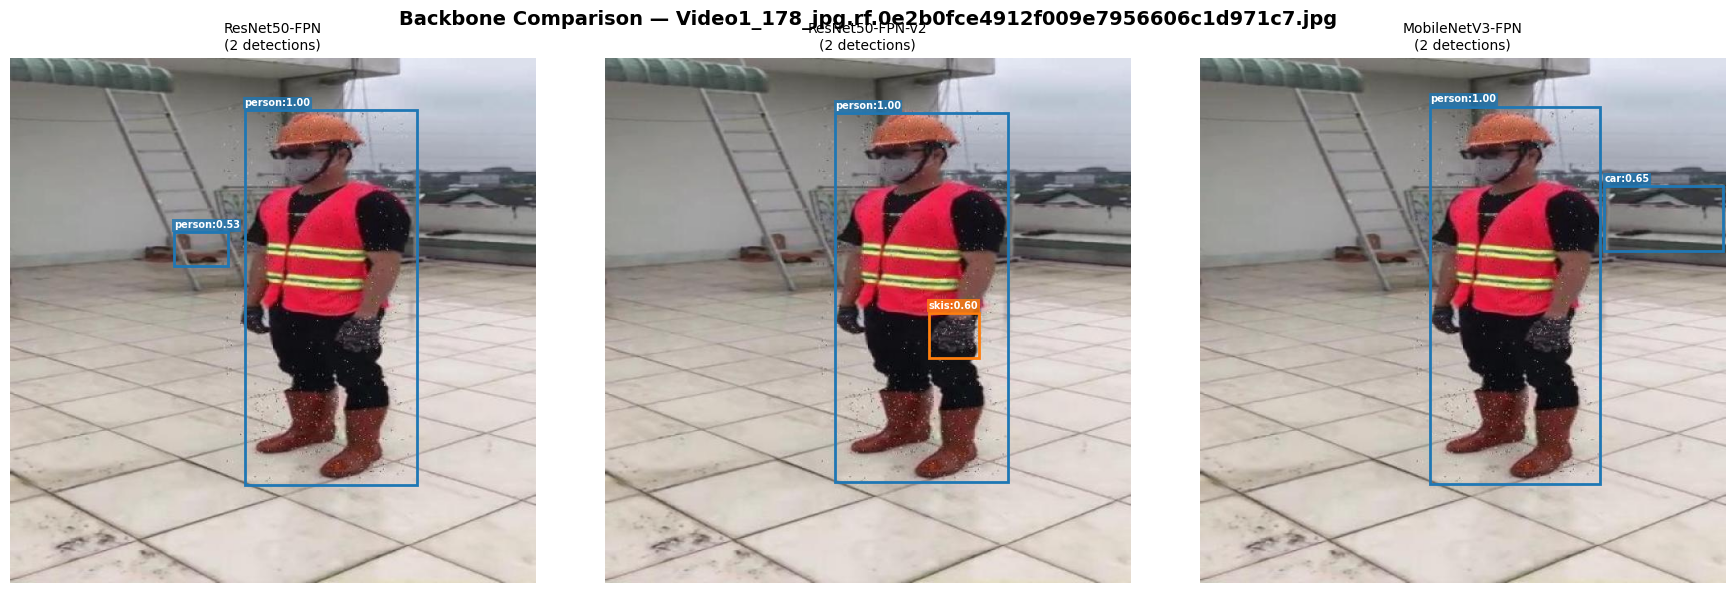

Saved: /content/comparison_Video1_178_jpg.rf.0e2b0fce4912f009e7956606c1d971c7.png

=== Image: 0_90525429_jpg.rf.c4ca40a3ef095b7b55c13241e85d5f54.jpg ===
Loading image from: /content/my_images/train/0_90525429_jpg.rf.c4ca40a3ef095b7b55c13241e85d5f54.jpg
Loading image from: /content/my_images/train/0_90525429_jpg.rf.c4ca40a3ef095b7b55c13241e85d5f54.jpg
Loading image from: /content/my_images/train/0_90525429_jpg.rf.c4ca40a3ef095b7b55c13241e85d5f54.jpg


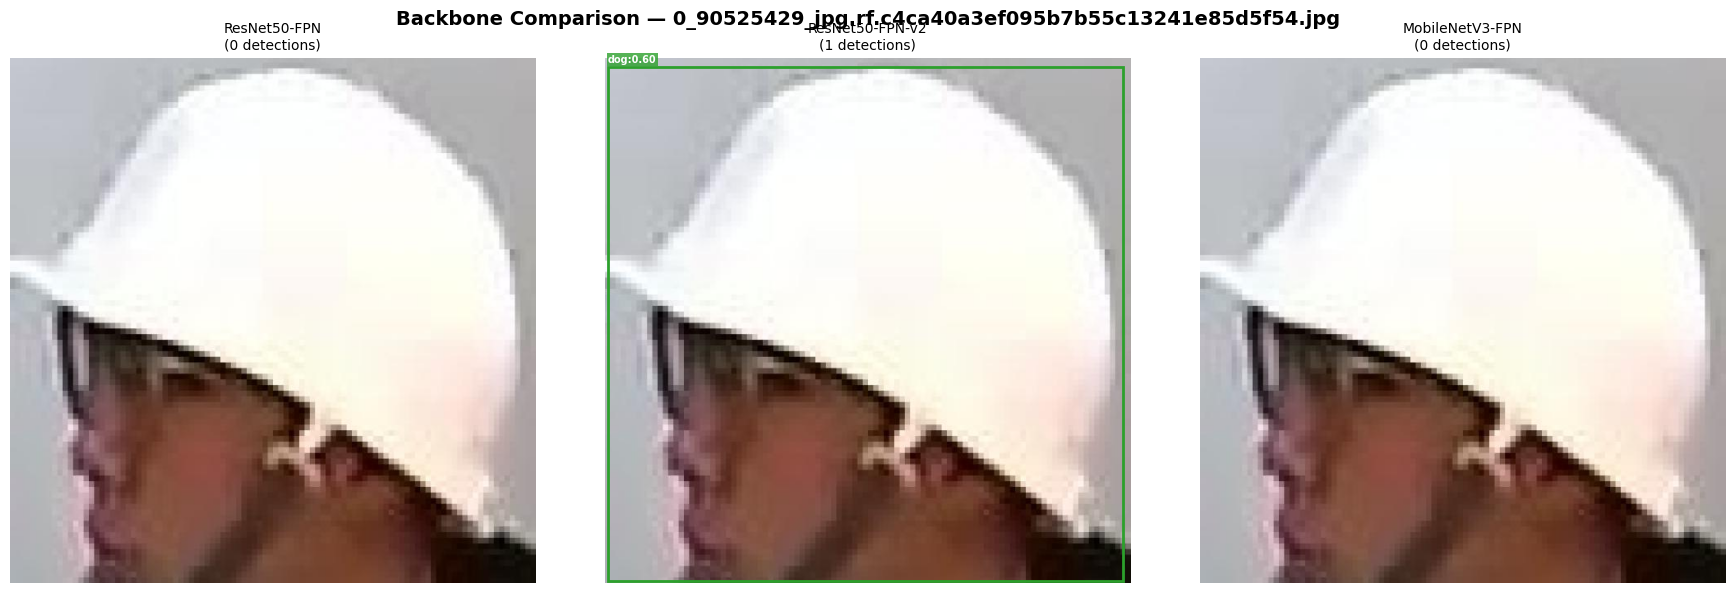

Saved: /content/comparison_0_90525429_jpg.rf.c4ca40a3ef095b7b55c13241e85d5f54.png

=== Image: 0_60800520_jpg.rf.b79bd5ed1c45913a18556cdc4b1ba46f.jpg ===
Loading image from: /content/my_images/train/0_60800520_jpg.rf.b79bd5ed1c45913a18556cdc4b1ba46f.jpg
Loading image from: /content/my_images/train/0_60800520_jpg.rf.b79bd5ed1c45913a18556cdc4b1ba46f.jpg
Loading image from: /content/my_images/train/0_60800520_jpg.rf.b79bd5ed1c45913a18556cdc4b1ba46f.jpg


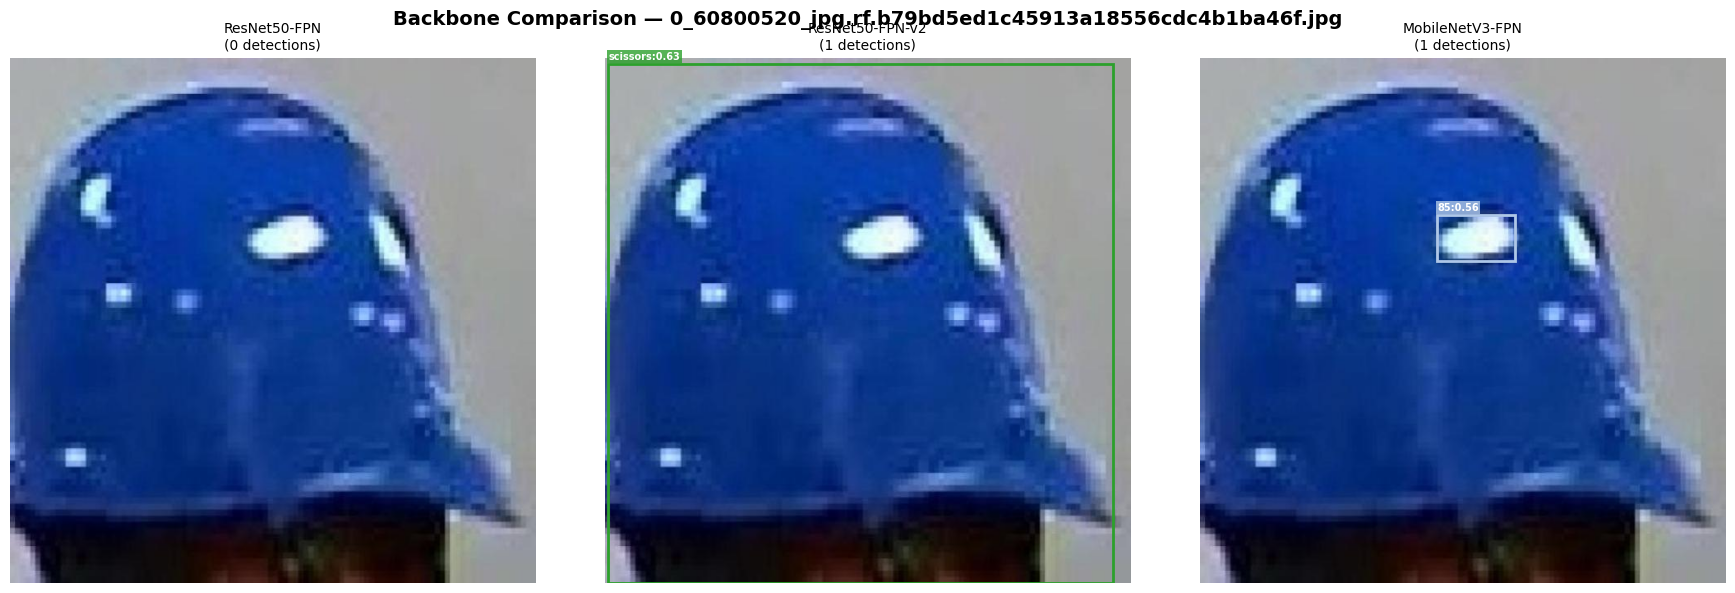

Saved: /content/comparison_0_60800520_jpg.rf.b79bd5ed1c45913a18556cdc4b1ba46f.png


In [6]:
SCORE_THRESHOLD = 0.5
NUM_DEMO_IMAGES = min(3, len(image_paths))   # show up to 3 images

demo_images = random.sample(image_paths, NUM_DEMO_IMAGES)

for img_path in demo_images:
    img_name = os.path.basename(img_path)
    print(f'\n=== Image: {img_name} ===')

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'Backbone Comparison — {img_name}', fontsize=14, fontweight='bold')

    for ax, (model_name, model) in zip(axes, MODELS.items()):
        image_rgb, boxes, class_indices, scores = detect_objects(
            img_path, model, threshold=SCORE_THRESHOLD
        )
        ax.imshow(image_rgb)
        for box, cls_idx, score in zip(boxes, class_indices, scores):
            x1, y1, x2, y2 = box
            colour = COLOUR_MAP(cls_idx % 20)
            rect   = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor=colour, facecolor='none'
            )
            ax.add_patch(rect)
            label = COCO_CLASSES[cls_idx] if cls_idx < len(COCO_CLASSES) else str(cls_idx)
            ax.text(x1, y1 - 5, f'{label}:{score:.2f}',
                    fontsize=7, color='white', fontweight='bold',
                    bbox=dict(facecolor=colour, alpha=0.8, pad=1, edgecolor='none'))
        ax.set_title(f'{model_name}\n({len(boxes)} detections)', fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    save_name = f'/content/comparison_{os.path.splitext(img_name)[0]}.png'
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_name}')


In [7]:
import math

print('=' * 60)
print('FASTER R-CNN FORWARD PASS — NUMERICAL WALKTHROUGH')
print('=' * 60)

# ── Stage 1: Feature Map ─────────────────────────────────────────────────────
input_size   = (256, 256)
feature_size = (64, 64)
anchors_per_loc = 3
total_anchors = feature_size[0] * feature_size[1] * anchors_per_loc
print(f'\n[Stage 1] Input Image : {input_size}')
print(f'          Feature Map  : {feature_size}  (after CNN backbone)')
print(f'          Total Anchors: {feature_size[0]} x {feature_size[1]} x {anchors_per_loc} = {total_anchors:,}')

# ── Stage 2: Objectness Scores (sigmoid) ─────────────────────────────────────
def sigmoid(x):
    return 1 / (1 + math.exp(-x))

raw_scores = [2.2, -0.85, 0.0]   # hypothetical RPN logits
print('\n[Stage 2] RPN Objectness Scores (sigmoid):')
for i, s in enumerate(raw_scores):
    p = sigmoid(s)
    print(f'  Anchor {i+1}: logit={s:+.2f}  ->  p_object = {p:.4f}')

# ── Stage 3: Bounding Box Regression ────────────────────────────────────────
gt     = {'x': 100, 'y': 100, 'w': 100, 'h': 100}
anchor = {'x':  80, 'y':  80, 'w': 120, 'h': 120}

dx = (gt['x'] - anchor['x']) / anchor['w']
dy = (gt['y'] - anchor['y']) / anchor['h']
dw = math.log(gt['w'] / anchor['w'])
dh = math.log(gt['h'] / anchor['h'])

print('\n[Stage 3] BBox Regression (Anchor 1):')
print(f'  GT box     : x={gt["x"]}, y={gt["y"]}, w={gt["w"]}, h={gt["h"]}')
print(f'  Anchor box : x={anchor["x"]}, y={anchor["y"]}, w={anchor["w"]}, h={anchor["h"]}')
print(f'  Δx = {dx:.3f},  Δy = {dy:.3f},  Δw = {dw:.3f},  Δh = {dh:.3f}')

# ── Stage 4: Region Proposal (apply adjustments) ─────────────────────────────
x_pred = anchor['x'] + dx * anchor['w']
y_pred = anchor['y'] + dy * anchor['h']
w_pred = anchor['w'] * math.exp(dw)
h_pred = anchor['h'] * math.exp(dh)

print('\n[Stage 4] Refined Region Proposal:')
print(f'  x={x_pred:.2f}, y={y_pred:.2f}, w={w_pred:.2f}, h={h_pred:.2f}')

# ── Stage 5: Detection Head (second regression) ──────────────────────────────
dx2, dy2, dw2, dh2 = 0.05, 0.05, -0.1, -0.1
x_final = x_pred + dx2
y_final = y_pred + dy2
w_final = w_pred * math.exp(dw2)
h_final = h_pred * math.exp(dh2)

print('\n[Stage 5] Final Detection Box (after detection head refinement):')
print(f'  x={x_final:.2f}, y={y_final:.2f}, w={w_final:.2f}, h={h_final:.2f}')
print(f'  Class probabilities: Car=0.90, Person=0.10')

# ── Loss Functions ────────────────────────────────────────────────────────────
def smooth_l1(x):
    return 0.5 * x**2 if abs(x) < 1 else abs(x) - 0.5

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-9
    return -(y_true * math.log(y_pred + eps) + (1 - y_true) * math.log(1 - y_pred + eps))

print('\n[Losses]')
rpn_cls_loss = binary_cross_entropy(1, sigmoid(2.2))
print(f'  RPN Classification Loss (BCE, anchor1 = object): {rpn_cls_loss:.4f}')
rpn_box_loss = sum(smooth_l1(d) for d in [dx, dy, dw, dh])
print(f'  RPN BBox Regression Loss (Smooth L1, anchor1)  : {rpn_box_loss:.4f}')

det_cls_loss = -math.log(0.9)           # car probability
det_box_loss = sum(smooth_l1(d) for d in [dx2, dy2, dw2, dh2])
print(f'  Detection Classification Loss (CE, car)        : {det_cls_loss:.4f}')
print(f'  Detection BBox Regression Loss (Smooth L1)     : {det_box_loss:.4f}')
print(f'  Total Loss = {rpn_cls_loss + rpn_box_loss + det_cls_loss + det_box_loss:.4f}')

FASTER R-CNN FORWARD PASS — NUMERICAL WALKTHROUGH

[Stage 1] Input Image : (256, 256)
          Feature Map  : (64, 64)  (after CNN backbone)
          Total Anchors: 64 x 64 x 3 = 12,288

[Stage 2] RPN Objectness Scores (sigmoid):
  Anchor 1: logit=+2.20  ->  p_object = 0.9002
  Anchor 2: logit=-0.85  ->  p_object = 0.2994
  Anchor 3: logit=+0.00  ->  p_object = 0.5000

[Stage 3] BBox Regression (Anchor 1):
  GT box     : x=100, y=100, w=100, h=100
  Anchor box : x=80, y=80, w=120, h=120
  Δx = 0.167,  Δy = 0.167,  Δw = -0.182,  Δh = -0.182

[Stage 4] Refined Region Proposal:
  x=100.00, y=100.00, w=100.00, h=100.00

[Stage 5] Final Detection Box (after detection head refinement):
  x=100.05, y=100.05, w=90.48, h=90.48
  Class probabilities: Car=0.90, Person=0.10

[Losses]
  RPN Classification Loss (BCE, anchor1 = object): 0.1051
  RPN BBox Regression Loss (Smooth L1, anchor1)  : 0.0610
  Detection Classification Loss (CE, car)        : 0.1054
  Detection BBox Regression Loss (Smooth 

In [8]:
def calculate_iou(box1, box2):
    """Compute IoU between [x1,y1,x2,y2] boxes."""
    ix1 = max(box1[0], box2[0])
    iy1 = max(box1[1], box2[1])
    ix2 = min(box1[2], box2[2])
    iy2 = min(box1[3], box2[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    a1    = (box1[2]-box1[0]) * (box1[3]-box1[1])
    a2    = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0.0

# Test
b1 = [80, 80, 200, 200]
b2 = [100, 100, 200, 200]
print(f'IoU between {b1} and {b2} = {calculate_iou(b1, b2):.4f}')

IoU between [80, 80, 200, 200] and [100, 100, 200, 200] = 0.6944


In [9]:
def calculate_precision_recall(pred_boxes, pred_scores, pred_labels,
                                gt_boxes, gt_labels, iou_threshold=0.5):
    tp, fp = 0, 0
    matched_gt = set()
    order = np.argsort(-np.array(pred_scores))

    for i in order:
        best_iou, best_j = 0, -1
        for j, gt_box in enumerate(gt_boxes):
            if gt_labels[j] == pred_labels[i] and j not in matched_gt:
                iou = calculate_iou(pred_boxes[i], gt_box)
                if iou > best_iou:
                    best_iou, best_j = iou, j
        if best_iou >= iou_threshold:
            tp += 1
            matched_gt.add(best_j)
        else:
            fp += 1

    fn        = len(gt_boxes) - len(matched_gt)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return precision, recall

print('calculate_precision_recall() defined.')

calculate_precision_recall() defined.


In [10]:
def calculate_ap(precisions, recalls):
    """Interpolated AP via rectangular integration."""
    prec = [0.0] + list(precisions) + [0.0]
    rec  = [0.0] + list(recalls)    + [1.0]
    for i in range(len(prec) - 2, -1, -1):
        prec[i] = max(prec[i], prec[i + 1])
    idx = [i for i in range(1, len(rec)) if rec[i] != rec[i - 1]]
    return sum((rec[i] - rec[i - 1]) * prec[i] for i in idx)


def calculate_map_from_model(model, image_paths, gt_data,
                              iou_threshold=0.5, score_threshold=0.5,
                              num_classes=81):
    """
    Compute mAP for a model over a list of images.

    gt_data: list of dicts {'boxes': [[x1,y1,x2,y2],...], 'labels': [int,...]}
             One entry per image, matching order of image_paths.
             Pass None to skip mAP and only return detections.
    """
    model.eval()
    all_preds, all_gts = [], []

    for i, img_path in enumerate(image_paths):
        img_rgb, boxes, cls_ids, scores = detect_objects(
            img_path, model, threshold=score_threshold
        )
        all_preds.append({'boxes': boxes, 'scores': scores, 'labels': cls_ids})
        if gt_data is not None:
            all_gts.append(gt_data[i])

    if gt_data is None:
        print('No ground truth provided — skipping mAP.')
        return None, all_preds

    average_precisions = []
    for cls_id in range(1, num_classes):
        precs, recs = [], []
        for pred, gt in zip(all_preds, all_gts):
            pb = [b for b, l in zip(pred['boxes'],  pred['labels']) if l == cls_id]
            ps = [s for s, l in zip(pred['scores'], pred['labels']) if l == cls_id]
            gb = [b for b, l in zip(gt['boxes'],    gt['labels'])   if l == cls_id]
            if not pb and not gb:
                continue
            p, r = calculate_precision_recall(
                pb, ps, [cls_id] * len(pb),
                gb,     [cls_id] * len(gb), iou_threshold
            )
            precs.append(p); recs.append(r)
        if precs:
            average_precisions.append(calculate_ap(precs, recs))

    mAP = float(np.mean(average_precisions)) if average_precisions else 0.0
    return mAP, all_preds

print('calculate_map_from_model() defined.')

calculate_map_from_model() defined.


In [11]:
# ── Load COCO ground truth if available ──────────────────────────────────────
gt_data = None
if coco_json_path:
    print(f'Loading COCO annotations from {coco_json_path} ...')
    with open(coco_json_path) as f:
        coco = json.load(f)

    id2fname = {img['id']: img['file_name'] for img in coco['images']}
    id2anns  = {img['id']: [] for img in coco['images']}
    for ann in coco['annotations']:
        id2anns[ann['image_id']].append(ann)

    # Build gt_data aligned with image_paths
    fname2id = {os.path.basename(v): k for k, v in id2fname.items()}
    gt_data = []
    for ip in image_paths:
        fname = os.path.basename(ip)
        img_id = fname2id.get(fname)
        if img_id is None:
            gt_data.append({'boxes': [], 'labels': []})
            continue
        boxes, labels = [], []
        for ann in id2anns[img_id]:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])
            labels.append(ann['category_id'])
        gt_data.append({'boxes': boxes, 'labels': labels})
    print(f'Ground truth loaded for {len(gt_data)} images.')
else:
    print('No COCO JSON found — inference only (mAP skipped).')

# ── Run all three models ──────────────────────────────────────────────────────
results = {}
for model_name, model in MODELS.items():
    print(f'\n--- Evaluating {model_name} ---')
    mAP, preds = calculate_map_from_model(
        model, image_paths, gt_data,
        iou_threshold=0.5, score_threshold=0.5
    )
    total_dets = sum(len(p['boxes']) for p in preds)
    results[model_name] = {'mAP': mAP, 'total_detections': total_dets}
    if mAP is not None:
        print(f'  mAP@0.5 = {mAP:.4f}   |   Total detections = {total_dets}')
    else:
        print(f'  Total detections = {total_dets}  (no GT for mAP)')

# ── Summary Table ─────────────────────────────────────────────────────────────
print('\n' + '='*55)
print(f'{"Model":<25} {"mAP@0.5":>10} {"Detections":>12}')
print('-'*55)
for name, r in results.items():
    mAP_str = f"{r['mAP']:.4f}" if r['mAP'] is not None else 'N/A (no GT)'
    print(f'{name:<25} {mAP_str:>10} {r["total_detections"]:>12}')
print('='*55)

Loading COCO annotations from /content/my_images/valid/_annotations.coco.json ...
Ground truth loaded for 257 images.

--- Evaluating ResNet50-FPN ---
Loading image from: /content/my_images/test/0_86004889_jpg.rf.a7b5abf422b797b44990adce07d5b9eb.jpg
Loading image from: /content/my_images/test/0_90497142_jpg.rf.23efeaa8a3e8ebb42fdab847b239adb1.jpg
Loading image from: /content/my_images/test/2_0_11247674_jpg.rf.2ff4a7141bcb511b6434bd1b31a8b97d.jpg
Loading image from: /content/my_images/test/2_0_59820113_jpg.rf.2b57f33dc5b315f59ea70fe895f9824d.jpg
Loading image from: /content/my_images/test/2_0_86778861_jpg.rf.b74270c62380cba76639b28bdb035902.jpg
Loading image from: /content/my_images/test/Tan0639639_jpg.rf.98a7f9b6e83ed3a5d76207bafe670882.jpg
Loading image from: /content/my_images/test/ppe_1138_jpg.rf.355e5ac7de880f46a220b8f0a46b2dc6.jpg
Loading image from: /content/my_images/test/ppe_1171_jpg.rf.23dcc5437b5e015f46873b0cecb5f8da.jpg
Loading image from: /content/my_images/test/ppe_1212_jp

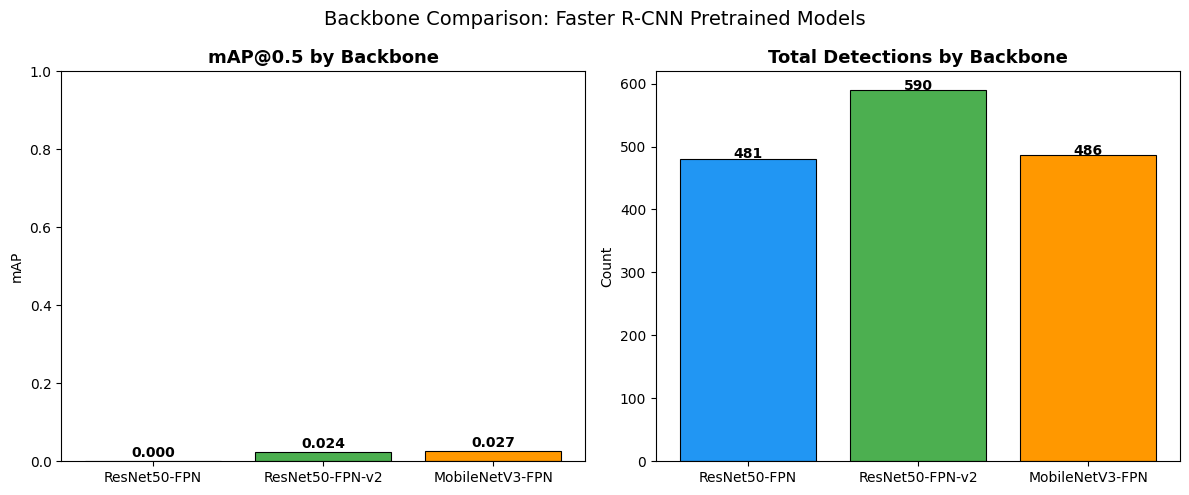

Comparison chart saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

names = list(results.keys())
maps  = [r['mAP'] if r['mAP'] is not None else 0 for r in results.values()]
dets  = [r['total_detections'] for r in results.values()]
colours = ['#2196F3', '#4CAF50', '#FF9800']

# mAP bar
axes[0].bar(names, maps, color=colours, edgecolor='black', linewidth=0.8)
axes[0].set_title('mAP@0.5 by Backbone', fontsize=13, fontweight='bold')
axes[0].set_ylabel('mAP')
axes[0].set_ylim(0, 1)
for i, v in enumerate(maps):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Detection count bar
axes[1].bar(names, dets, color=colours, edgecolor='black', linewidth=0.8)
axes[1].set_title('Total Detections by Backbone', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(dets):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.suptitle('Backbone Comparison: Faster R-CNN Pretrained Models', fontsize=14)
plt.tight_layout()
plt.savefig('/content/backbone_comparison.png', dpi=150)
plt.show()
print('Comparison chart saved.')

Manual AP (tutorial table): 0.8100  (expected ≈ 0.81)

Interval-by-interval breakdown:
Recall Interval       Precision     Area
----------------------------------------
0.0 → 0.1                   1.00   0.1000
0.1 → 0.2                   0.90   0.0900
0.2 → 0.4                   0.85   0.1700
0.4 → 0.6                   0.80   0.1600
0.6 → 0.8                   0.75   0.1500
0.8 → 1.0                   0.70   0.1400
                               AP = 0.8100


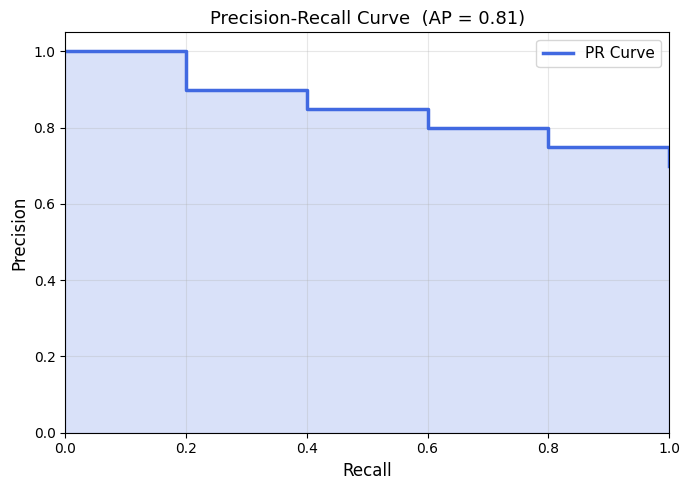

In [13]:
# Manual AP walkthrough from tutorial
recall_pts    = [0.0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
precision_pts = [1.0, 1.0, 0.9, 0.85, 0.80, 0.75, 0.70]

ap_manual = calculate_ap(precision_pts[1:], recall_pts[1:])
print(f'Manual AP (tutorial table): {ap_manual:.4f}  (expected ≈ 0.81)')

# Area fill calculation breakdown
intervals = list(zip(recall_pts[:-1], recall_pts[1:], precision_pts[1:]))
print('\nInterval-by-interval breakdown:')
print(f'{"Recall Interval":<20} {"Precision":>10} {"Area":>8}')
print('-' * 40)
total = 0
for r0, r1, p in intervals:
    area = (r1 - r0) * p
    total += area
    print(f'{r0:.1f} → {r1:.1f}             {p:>10.2f} {area:>8.4f}')
print(f'{"":<30} AP = {total:.4f}')

# PR Curve plot
plt.figure(figsize=(7, 5))
plt.step(recall_pts, precision_pts, where='post', color='royalblue', lw=2.5, label='PR Curve')
plt.fill_between(recall_pts, precision_pts, alpha=0.2, color='royalblue', step='post')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title(f'Precision-Recall Curve  (AP = {ap_manual:.2f})', fontsize=13)
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('/content/pr_curve.png', dpi=150)
plt.show()

In [14]:
output_files = [
    '/content/backbone_comparison.png',
    '/content/pr_curve.png',
]
# also grab comparison images
for f in os.listdir('/content'):
    if f.startswith('comparison_') and f.endswith('.png'):
        output_files.append(f'/content/{f}')

for fpath in output_files:
    if os.path.exists(fpath):
        print(f'Downloading: {fpath}')
        files.download(fpath)
    else:
        print(f'Not found (skipping): {fpath}')

Downloading: /content/backbone_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: /content/pr_curve.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: /content/comparison_0_60800520_jpg.rf.b79bd5ed1c45913a18556cdc4b1ba46f.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>